<a href="https://colab.research.google.com/github/Ravravan/ML/blob/main/linear_regression_assumptions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/data.csv')

In [3]:
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [4]:
x= df.iloc[:,0:3].values
y= df.iloc[:,-1].values

In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=1)

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
model= LinearRegression()

In [8]:
model.fit(x_train,y_train)

LinearRegression()

In [9]:
#Residual
y_pred = model.predict(x_test)
residual = y_test - y_pred



#Linear Relationship   



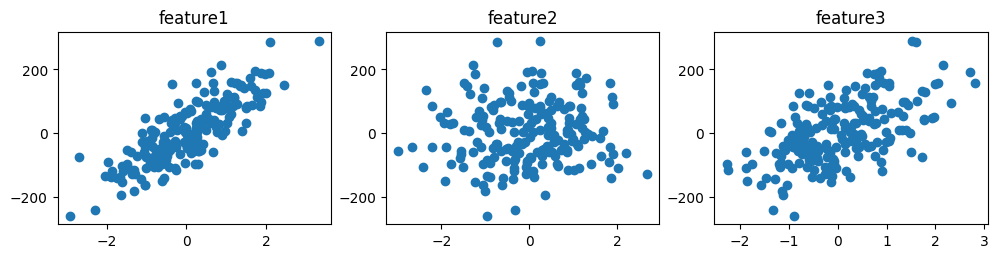

In [13]:
fig,(ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12,2.5))

ax1.scatter(df['feature1'],df['target'])
ax1.set_title('feature1')
ax2.scatter(df['feature2'],df['target'])
ax2.set_title('feature2')
ax3.scatter(df['feature3'],df['target'])
ax3.set_title('feature3')

plt.show()

#Multiconllinearity

In [15]:

from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = []



for i in range(x_train.shape[1]):

  vif.append(variance_inflation_factor(x_train, i))




In [17]:
pd.DataFrame({'vif':vif},index=df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.010326,1.009871,1.01395


<Axes: >

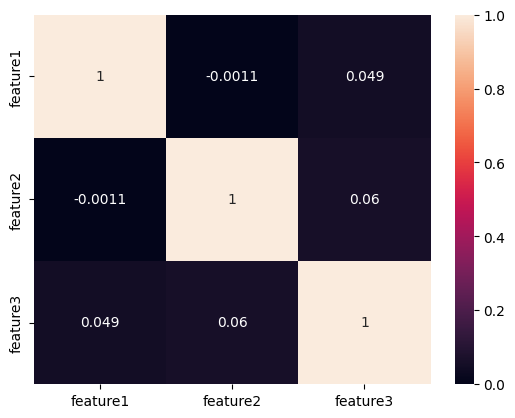

In [18]:
#another Technique
sns.heatmap(df.iloc[:,0:3].corr(),annot=True)

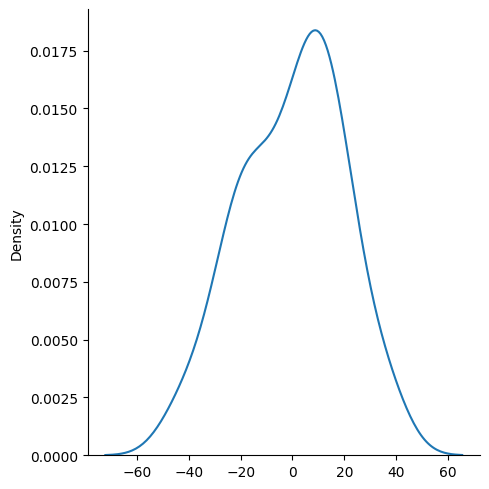

In [19]:
sns.displot(residual,kind='kde')

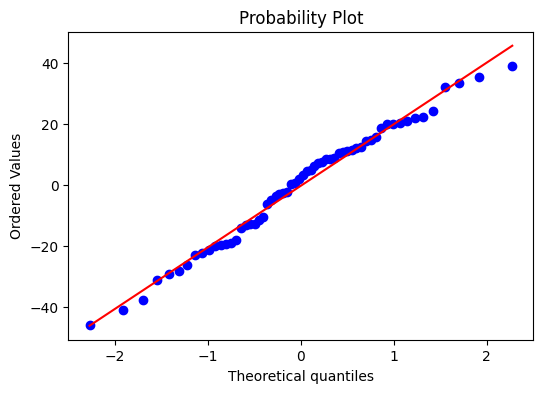

In [21]:
# QQ plot

import scipy as sp

fig, ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual, plot=ax, fit=True)
plt.show()

#Homoscedasticity